In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
x_train = np.array([1.0, 2.0])  #House size
y_train = np.array([300, 500])  # House price  
m = x_train.shape[0]
print(f" Siz: {m}")

 Siz: 2


In [23]:
# Cost function: difference squared mean
# J(W) = (1/2m) * ((Y - y^) ** 2)
#  i.e Cost = Y_train - y_guess
# Y = wx + b

def compute_cost(x, y, w, b):
    total = 0
    for i in range(m):
        y_guess = w*x[i] + b
        error = (y[i] - y_guess) ** 2
        total += error

    cost = (1 / (2 * m)) * total
    return cost


In [24]:
def compute_gradient(x, y, w, b):
    total = 0
    dj_dw = 0
    dj_db = 0
    for i in range(m):
        diff = w*x[i] + b
        error = (diff - y[i]) * x[i]
        total += error
    dj_dw = total / m

    total = 0
    
    for i in range(m):
        diff = w*x[i] + b
        error = diff - y[i]
        total += error
    dj_db = total / m

    return dj_dw, dj_db

In [25]:
# Gradient Descent:
def gradient_descent(x, y, w_init, b_init, learning_rate, num_inters):
    j_history = []
    p_history = []
    b = b_init
    w = w_init

    for i in range(num_inters):
        dj_dw, dj_db = compute_gradient(x, y, w, b)
        w = w - learning_rate * dj_dw
        b  = b - learning_rate * dj_db
        if i<100000:      # prevent resource exhaustion 
            cost = compute_cost(x, y, w, b)
            j_history.append(cost)
            p_history.append([w,b])
    
        if i % 100 == 0:
            print(f"Iteration {i}: Cost {j_history[-1]:0.2e} ",
                    f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}  ",
                    f"w: {w: 0.3e}, b:{b: 0.5e}")


    return w, b, j_history, p_history

In [31]:
w_init = 0
b_init = 0

iterations = 10000
alpha = 1.0e-2

w_final, b_final, j_history, p_history = gradient_descent(x_train, y_train, w_init, b_init, alpha, iterations)


print(f"Result (w, b): ({w_final:8.4f}, {b_final:8.4f})")

Iteration 0: Cost 7.93e+04  dj_dw: -6.500e+02, dj_db: -4.000e+02   w:  6.500e+00, b: 4.00000e+00
Iteration 100: Cost 8.68e+01  dj_dw: -2.057e+01, dj_db: -1.111e+01   w:  1.846e+02, b: 1.12410e+02
Iteration 200: Cost 1.10e+01  dj_dw: -1.273e+00, dj_db:  7.015e-01   w:  1.907e+02, b: 1.14646e+02
Iteration 300: Cost 9.48e+00  dj_dw: -6.373e-01, dj_db:  9.896e-01   w:  1.915e+02, b: 1.13710e+02
Iteration 400: Cost 8.19e+00  dj_dw: -5.757e-01, dj_db:  9.303e-01   w:  1.921e+02, b: 1.12748e+02
Iteration 500: Cost 7.08e+00  dj_dw: -5.347e-01, dj_db:  8.651e-01   w:  1.927e+02, b: 1.11851e+02
Iteration 600: Cost 6.12e+00  dj_dw: -4.971e-01, dj_db:  8.043e-01   w:  1.932e+02, b: 1.11017e+02
Iteration 700: Cost 5.29e+00  dj_dw: -4.621e-01, dj_db:  7.477e-01   w:  1.937e+02, b: 1.10242e+02
Iteration 800: Cost 4.57e+00  dj_dw: -4.296e-01, dj_db:  6.950e-01   w:  1.941e+02, b: 1.09521e+02
Iteration 900: Cost 3.95e+00  dj_dw: -3.993e-01, dj_db:  6.461e-01   w:  1.945e+02, b: 1.08851e+02
Iteration 10

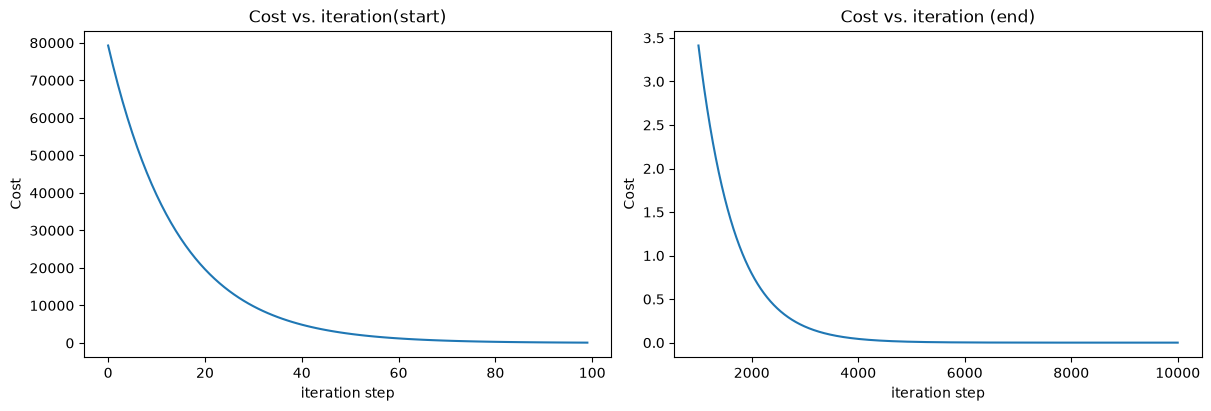

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(j_history[:100])
ax2.plot(1000 + np.arange(len(j_history[1000:])), j_history[1000:])
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step') 
plt.show()

In [33]:
print(f"1000 sqft house prediction {w_final*1.0 + b_final:0.1f} Thousand dollars")
print(f"1200 sqft house prediction {w_final*1.2 + b_final:0.1f} Thousand dollars")
print(f"2000 sqft house prediction {w_final*2.0 + b_final:0.1f} Thousand dollars")

1000 sqft house prediction 300.0 Thousand dollars
1200 sqft house prediction 340.0 Thousand dollars
2000 sqft house prediction 500.0 Thousand dollars
